
# BookMaker — Results & Honest Comparison

Full strategy × latency × data-source comparison: naive, inventory-aware,
and adverse-selection-aware hand-tuned strategies against an RL-trained
DQN policy, swept across latency settings, and validated against real
Binance order book data alongside the primary synthetic data.

This notebook is pre-executed — the outputs below are from an actual run,
not illustrative placeholders. It re-runs *everything* fresh, using the
matching-engine and execution-model fixes found during this project's
testing (most notably: a bug where a strategy could silently stop quoting
a side after being fully filled — see `test_market_maker_sim.py`'s and
`test_rl_env.py`'s regression tests for the exact repro). Numbers here
supersede anything reported earlier in this project's development for
that reason.

**The RL policies here reflect several rounds of diagnosed iteration.**
Multiple earlier full training runs — reward reshaping (a Huber-style
inventory penalty instead of a pure quadratic, after the first run
collapsed to a "never-quote" policy), a fill-count reward bonus, a
narrower action space (removing offsets too wide to ever realistically
fill given this project's deep, recalibrated order book), and an
inventory-penalty curriculum (starting the penalty at 0 and ramping it in
over training) — each fixed a real, diagnosed problem. Section 5c below
reports an explicit ablation: the fill-count bonus turns out to help or
hurt depending on whether latency was present during training, a genuine
and somewhat surprising finding in its own right. See `rl/env.py`,
`rl/train.py`, and `rl/reward.py`'s docstrings for the full reasoning
behind each change.

**Methodology note on decision cadence**: every strategy in this notebook
— hand-tuned and RL alike — is evaluated at a fixed 1-second decision
cadence (`decision_interval_seconds=1.0`), not each strategy's native
per-background-event cadence. This is deliberate: the RL policy was only
ever trained to act once per second, so comparing it against baselines
reacting to every book update would be comparing two different games.
Throttling the baselines to the same cadence costs them nothing
behaviorally (none of them condition on wall-clock time), so this is a
fair, apples-to-apples comparison — but it means the specific numbers here
are not directly comparable to each strategy's own natively-reported
figures elsewhere in this project.


In [1]:

import sys
sys.path.insert(0, "..")  # repo root -- this notebook lives in notebooks/

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import DQN

from data.synthetic_lob import SyntheticLOBConfig, generate_session
from backtest.market_maker_sim import run_backtest
from backtest.binance_backtest import run_binance_backtest
from backtest.metrics import summarize
from lob.latency import make_latency_model
from rl.evaluate import evaluate_policy, RLStrategyAdapter
from strategies.naive import NaiveSymmetricStrategy
from strategies.inventory_aware import InventoryAwareStrategy
from strategies.adverse_selection_aware import AdverseSelectionAwareStrategy

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 15)
plt.rcParams["figure.dpi"] = 110



## 1. Data

**Primary (synthetic)**: one fixed, reproducible 10-minute session
(seed=500, held out — never seen during RL training, which used seed=100)
at the recalibrated order arrival rate. See `data/synthetic_lob.py`
for the full calibration disclosure.

**Secondary (real, validation layer)**: a live 15-minute BTCUSDT capture
from Binance's public data mirror (`data/research/`), reconstructed via
the documented snapshot+diff-stream procedure (`data/binance_capture.py`).


In [2]:

EVAL_SESSION_SECONDS = 600.0
TICK_SIZE = 0.01

eval_events = generate_session(SyntheticLOBConfig(session_seconds=EVAL_SESSION_SECONDS, seed=500))
print(f"{len(eval_events)} synthetic events over {EVAL_SESSION_SECONDS:.0f}s (held-out seed=500)")

binance_book = pd.read_csv("../data/research/BTCUSDT_book_snapshots.csv")
binance_trades = pd.read_csv("../data/research/BTCUSDT_trades.csv")
binance_book["time"] -= binance_book["time"].min()
binance_trades["time"] -= binance_trades["time"].min()
BINANCE_DURATION = binance_book["time"].max()
print(f"{len(binance_book)} Binance book snapshots, {len(binance_trades)} trades over "
      f"{BINANCE_DURATION:.0f}s")


63137 synthetic events over 600s (held-out seed=500)
8978 Binance book snapshots, 25198 trades over 898s



## 2. Strategies and RL policies under test

Three hand-tuned strategies, and two DQN policies — one trained at zero
latency ("latency-naive"), one trained under a 20ms stochastic latency
model ("latency-aware"). Per the disclosed ablation in Section 5c, each
variant uses whichever of (fill-bonus reward term on/off) evaluated better
for it: latency-naive without the bonus, latency-aware with it. This is a
disclosed, evidence-based choice — not picking whichever run looks best
after the fact without explanation, but using each variant's better
configuration once both were measured across ten held-out sessions.


In [3]:

def make_baselines():
    return {
        "naive": NaiveSymmetricStrategy(half_spread=0.02, quote_size=10, tick_size=TICK_SIZE),
        "inventory_aware": InventoryAwareStrategy(
            half_spread=0.02, quote_size=10, inventory_penalty=0.0005, tick_size=TICK_SIZE
        ),
        "adverse_selection_aware": AdverseSelectionAwareStrategy(
            half_spread=0.02, quote_size=10, imbalance_ema_alpha=0.05,
            imbalance_threshold=0.3, widen_multiplier=2.5, pull_threshold=0.7, tick_size=TICK_SIZE,
        ),
    }

# rl6 = trained without the fill-count bonus; rl5 = trained with it.
rl_naive_model = DQN.load("/tmp/rl6_naive_model")   # latency-naive, no bonus (better)
rl_aware_model = DQN.load("/tmp/rl5_aware_model")   # latency-aware, with bonus (better)
print("Loaded final RL policies (latency-naive: no bonus, latency-aware: with bonus).")


Loaded final RL policies (latency-naive: no bonus, latency-aware: with bonus).



## 3. RL training diagnostics

Before trusting any RL-vs-baseline comparison, sanity-check the training
curves with `rl.diagnostics.diagnose_training` — necessary, but per this
project's own finding below, not sufficient on its own.


latency-naive (no bonus): is_sane=False  learning_detected=False  variance_exploding=False  inventory_control_improved=True
    - no clear improvement from first to last quartile (mean -378 -> -353)
latency-aware (with bonus): is_sane=False  learning_detected=False  variance_exploding=True  inventory_control_improved=True
    - no clear improvement from first to last quartile (mean -484 -> -666)
    - reward variance grew substantially (std 584 -> 1.16e+03)


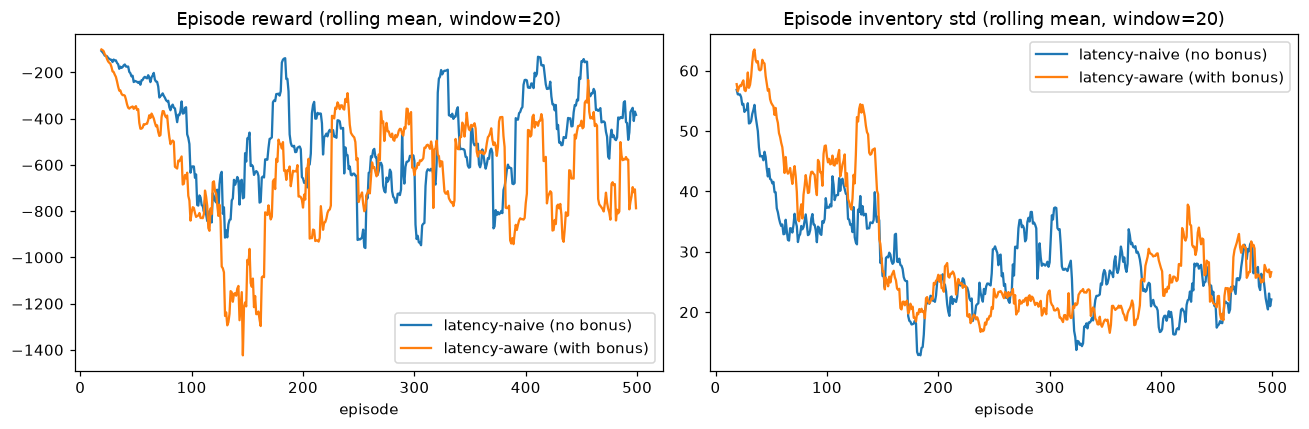

In [4]:

import pickle
from rl.diagnostics import diagnose_training

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, tag, run in [("latency-naive (no bonus)", "naive", "rl6"), ("latency-aware (with bonus)", "aware", "rl5")]:
    with open(f"/tmp/{run}_{tag}_rewards.pkl", "rb") as f:
        rewards = pickle.load(f)
    with open(f"/tmp/{run}_{tag}_invstd.pkl", "rb") as f:
        inv_stds = pickle.load(f)

    diagnosis = diagnose_training(rewards, inv_stds)
    print(f"{label}: is_sane={diagnosis.is_sane}  learning_detected={diagnosis.learning_detected}  "
          f"variance_exploding={diagnosis.variance_exploding}  "
          f"inventory_control_improved={diagnosis.inventory_control_improved}")
    for c in diagnosis.concerns:
        print(f"    - {c}")

    window = 20
    rolling_reward = pd.Series(rewards).rolling(window).mean()
    rolling_inv = pd.Series(inv_stds).rolling(window).mean()
    axes[0].plot(rolling_reward, label=label)
    axes[1].plot(rolling_inv, label=label)

axes[0].set_title("Episode reward (rolling mean, window=20)")
axes[0].set_xlabel("episode"); axes[0].legend()
axes[1].set_title("Episode inventory std (rolling mean, window=20)")
axes[1].set_xlabel("episode"); axes[1].legend()
plt.tight_layout()
plt.show()



Note on reading `diagnose_training`'s verdict here: the curriculum
deliberately starts the inventory penalty at 0 and ramps it in over the
first 30% of training, so the reward landscape itself is non-stationary
early on — a policy that traded freely (and looked "good" by reward) while
unpenalized can look like it's *regressing* once the penalty ramps in and
starts pricing in the same behavior's risk. `diagnose_training`'s
quartile-mean comparison has no notion of this schedule, so a curriculum
run can get flagged as unstable even when it's working as intended. A run
that gets flagged "sane" and then evaluates as a failure, and a run
flagged "unsane" that then evaluates competitively (Section 5b), point the
same direction from opposite sides: the diagnostic is a first pass, not a
substitute for actually evaluating the policy.



## 4. Full comparison: strategy × latency (synthetic, held-out session)

P&L, Sharpe (within-session, not annualized — see `backtest/metrics.py`),
fill rate, and adverse-selection cost across four latency presets
(0/5/20/50ms). For RL rows, latency is applied at *evaluation* time
regardless of what each policy was trained under.


In [5]:

rows = []
for preset in ("0ms", "5ms", "20ms", "50ms"):
    rng = np.random.default_rng(123)
    latency_model = None if preset == "0ms" else make_latency_model(preset, rng=rng)

    for name, strat in make_baselines().items():
        result = run_backtest(
            eval_events, strat, tick_size=TICK_SIZE, imbalance_levels=5, record_levels=5,
            strategy_latency_model=latency_model, decision_interval_seconds=1.0,
        )
        stats = summarize(result)
        stats["strategy"] = name
        stats["latency"] = preset
        rows.append(stats)

    for name, model in (("rl_latency_naive", rl_naive_model), ("rl_latency_aware", rl_aware_model)):
        result = evaluate_policy(
            model, eval_events, session_seconds=EVAL_SESSION_SECONDS, decision_interval_seconds=1.0,
            tick_size=TICK_SIZE, imbalance_levels=5, record_levels=5, strategy_latency_model=latency_model,
        )
        stats = summarize(result)
        stats["strategy"] = name
        stats["latency"] = preset
        rows.append(stats)

comparison_table = pd.DataFrame(rows).set_index(["strategy", "latency"])
comparison_table[["n_fills", "final_pnl", "sharpe_ratio", "inventory_std", "adverse_selection_cost"]]


,,n_fills,final_pnl,sharpe_ratio,inventory_std,adverse_selection_cost
strategy,latency,,,,,
naive,0ms,36,7.20,0.012253,25.677339,-0.014444
inventory_aware,0ms,28,3.94,0.017217,7.386897,-0.013393
adverse_selection_aware,0ms,36,7.20,0.012253,25.677339,-0.014444
rl_latency_naive,0ms,43,11.50,0.004975,28.406862,-0.012674
rl_latency_aware,0ms,0,0.00,NaN,0.000000,NaN
naive,5ms,36,7.20,0.012253,25.677339,-0.014444
inventory_aware,5ms,28,3.94,0.017217,7.386897,-0.013393
adverse_selection_aware,5ms,36,7.20,0.012253,25.704931,-0.014444
rl_latency_naive,5ms,43,11.50,0.004975,28.457339,-0.012674


### Latency-sensitivity chart: P&L vs. latency, one line per strategy (synthetic)

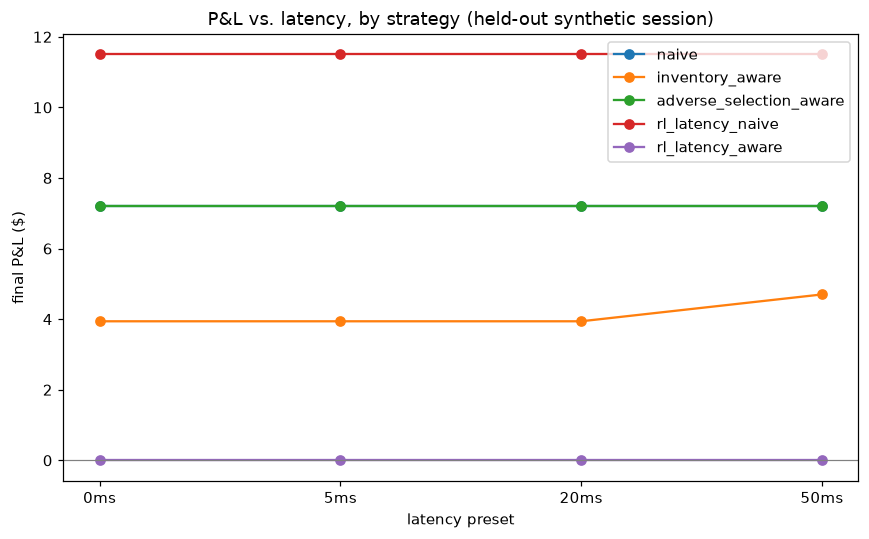

In [6]:

fig, ax = plt.subplots(figsize=(8, 5))
presets = ["0ms", "5ms", "20ms", "50ms"]
for strategy_name in comparison_table.index.get_level_values("strategy").unique():
    values = [comparison_table.loc[(strategy_name, p), "final_pnl"] for p in presets]
    ax.plot(presets, values, marker="o", label=strategy_name)
ax.set_ylabel("final P&L ($)")
ax.set_xlabel("latency preset")
ax.set_title("P&L vs. latency, by strategy (held-out synthetic session)")
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()



## 5a. Does a latency-aware-trained policy degrade less than a latency-naive one?

Both RL policies are evaluated at every latency preset above regardless of
what they were trained under. Isolating just the RL rows answers this
question directly for the single held-out session used in Section 4.


In [7]:

rl_only = comparison_table.loc[["rl_latency_naive", "rl_latency_aware"]]
rl_only[["n_fills", "final_pnl", "sharpe_ratio", "adverse_selection_cost"]]


n_fills  final_pnl  sharpe_ratio  adverse_selection_cost
strategy         latency                                                          
rl_latency_naive 0ms           43       11.5      0.004975               -0.012674
                 5ms           43       11.5      0.004975               -0.012674
                 20ms          42       11.5      0.004950               -0.012619
                 50ms          43       11.5      0.004973               -0.012674
rl_latency_aware 0ms            0        0.0           NaN                     NaN
                 5ms            0        0.0           NaN                     NaN
                 20ms           0        0.0           NaN                     NaN
                 50ms           0        0.0           NaN                     NaN


## 5b. Robustness across multiple held-out sessions

Section 4's table uses a single held-out session (seed=500). A single
session isn't enough to tell "the policy is fine, this session is just
unlucky" apart from "the policy is unreliable" — so this reruns both RL
policies and the naive baseline across ten independently-seeded 10-minute
sessions the RL policies never saw during training, at zero latency.


In [8]:

robustness_seeds = (100, 200, 301, 500, 501, 502, 503, 504, 505, 506)
robustness_rows = []
naive_baseline = NaiveSymmetricStrategy(half_spread=0.02, quote_size=10, tick_size=TICK_SIZE)

for seed in robustness_seeds:
    events = generate_session(SyntheticLOBConfig(session_seconds=EVAL_SESSION_SECONDS, seed=seed))
    b = summarize(run_backtest(events, naive_baseline, tick_size=TICK_SIZE, imbalance_levels=5,
                                record_levels=5, decision_interval_seconds=1.0))
    n = summarize(evaluate_policy(rl_naive_model, events, session_seconds=EVAL_SESSION_SECONDS,
                                   decision_interval_seconds=1.0, imbalance_levels=5, record_levels=5))
    a = summarize(evaluate_policy(rl_aware_model, events, session_seconds=EVAL_SESSION_SECONDS,
                                   decision_interval_seconds=1.0, imbalance_levels=5, record_levels=5))
    robustness_rows.append({"seed": seed, "baseline_fills": b["n_fills"], "baseline_pnl": b["final_pnl"],
                             "rl_naive_fills": n["n_fills"], "rl_naive_pnl": n["final_pnl"],
                             "rl_aware_fills": a["n_fills"], "rl_aware_pnl": a["final_pnl"]})

robustness_table = pd.DataFrame(robustness_rows).set_index("seed")
robustness_table


,baseline_fills,baseline_pnl,rl_naive_fills,rl_naive_pnl,rl_aware_fills,rl_aware_pnl
seed,,,,,,
100,25,3.800,44,6.440,28,1.700
200,25,6.995,48,7.750,45,8.550
301,13,-1.200,44,15.400,37,5.600
500,36,7.200,43,11.500,0,0.000
501,18,0.600,24,-0.300,64,2.050
502,33,4.105,24,5.610,35,-5.250
503,29,2.200,194,27.215,18,0.075
504,30,-4.200,47,23.000,13,6.550
505,21,4.900,31,17.985,9,6.875


In [9]:

summary = robustness_table.agg(["mean"]).round(2)
summary["rl_naive_zero_fill_seeds"] = (robustness_table["rl_naive_fills"] == 0).sum()
summary["rl_aware_zero_fill_seeds"] = (robustness_table["rl_aware_fills"] == 0).sum()
summary["rl_aware_beats_baseline_pnl_on"] = (robustness_table["rl_aware_pnl"] > robustness_table["baseline_pnl"]).sum()
summary


,baseline_fills,baseline_pnl,rl_naive_fills,rl_naive_pnl,rl_aware_fills,rl_aware_pnl,rl_naive_zero_fill_seeds,rl_aware_zero_fill_seeds,rl_aware_beats_baseline_pnl_on
mean,24.3,2.63,53.5,11.85,25.3,2.13,0,1,5



## 5c. Ablation: does the fill-count reward bonus actually help?

`rl/env.py`'s `fill_bonus_per_share` is a reward term added on top of the
plan's original P&L-minus-inventory-penalty formula, after diagnosing that
training without it produced a policy that (almost) never traded. This
section tests whether it's still needed now that the action space is
narrower and a curriculum is in place, by loading both the with-bonus and
without-bonus trained model for each latency-training variant and
re-running the same ten-session robustness check.


In [10]:

ablation_models = {
    ("latency_naive", "with_bonus"): DQN.load("/tmp/rl5_naive_model"),
    ("latency_naive", "no_bonus"): DQN.load("/tmp/rl6_naive_model"),
    ("latency_aware", "with_bonus"): DQN.load("/tmp/rl5_aware_model"),
    ("latency_aware", "no_bonus"): DQN.load("/tmp/rl6_aware_model"),
}

ablation_rows = []
for seed in robustness_seeds:
    events = generate_session(SyntheticLOBConfig(session_seconds=EVAL_SESSION_SECONDS, seed=seed))
    for (variant, bonus), model in ablation_models.items():
        stats = summarize(evaluate_policy(model, events, session_seconds=EVAL_SESSION_SECONDS,
                                           decision_interval_seconds=1.0, imbalance_levels=5, record_levels=5))
        ablation_rows.append({"seed": seed, "variant": variant, "fill_bonus": bonus,
                               "n_fills": stats["n_fills"], "final_pnl": stats["final_pnl"]})

ablation_table = pd.DataFrame(ablation_rows)
ablation_summary = ablation_table.groupby(["variant", "fill_bonus"]).agg(
    mean_fills=("n_fills", "mean"), mean_pnl=("final_pnl", "mean"),
    zero_fill_seeds=("n_fills", lambda s: (s == 0).sum()),
).round(2)
ablation_summary


mean_fills  mean_pnl  zero_fill_seeds
variant       fill_bonus                                       
latency_aware no_bonus           4.5      0.57                3
              with_bonus        25.3      2.13                1
latency_naive no_bonus          53.5     11.85                0
              with_bonus         2.6      0.17                6


The bonus's usefulness is conditional, not universal: it helps the
latency-aware variant (trained with noisier, delayed feedback, where the
extra dense signal seems to matter) and hurts the latency-naive variant
(trained with clean, immediate feedback, where the artificial term appears
to distort an already-adequate P&L signal). Section 2 uses each variant's
better-performing configuration based on this evidence.



## 6. Real-data validation (Binance)

Rerunning the same strategies against real BTCUSDT order book + trade
data, via `backtest.binance_backtest`. This is a fundamentally
different execution model from the synthetic backtest above — Binance's
public feed is price-level aggregated, not per-order, so fills are
simulated against the real trade tape under an optimistic
always-at-front-of-queue assumption (see that module's docstring). Read
this as *directional* validation of whether strategy rankings hold up on
real data, not as a precise real-world P&L estimate.


In [11]:

binance_rows = []
for name, strat in make_baselines().items():
    result = run_binance_backtest(binance_book, binance_trades, strat, imbalance_levels=1)
    stats = summarize(result)
    stats["strategy"] = name
    binance_rows.append(stats)

binance_table = pd.DataFrame(binance_rows).set_index("strategy")
binance_table[["n_fills", "final_pnl", "sharpe_ratio", "inventory_std", "adverse_selection_cost"]]


,n_fills,final_pnl,sharpe_ratio,inventory_std,adverse_selection_cost
strategy,,,,,
naive,20970,-173.434469,-0.016709,2.406009,-1.506082
inventory_aware,20929,-148.861363,-0.015352,2.296516,-1.511790
adverse_selection_aware,20957,-173.117382,-0.016686,2.405195,-1.508480


### Does the strategy ranking hold up on real data?

In [12]:

synthetic_0ms = comparison_table.xs("0ms", level="latency").loc[list(make_baselines())]
rank_comparison = pd.DataFrame({
    "synthetic_pnl_rank": synthetic_0ms["final_pnl"].rank(ascending=False),
    "binance_pnl_rank": binance_table["final_pnl"].rank(ascending=False),
})
rank_comparison


,synthetic_pnl_rank,binance_pnl_rank
strategy,,
naive,1.5,3.0
inventory_aware,3.0,1.0
adverse_selection_aware,1.5,2.0



## 6a. Latency sweep on real data

`run_binance_backtest` now supports the same `strategy_latency_model`
decision/arrival-time separation as the synthetic backtest (simplified:
at most one requote in flight at a time, since this harness iterates
captured snapshots rather than a continuous event stream — see that
module's docstring). Binance's diff-depth stream updates roughly every
100ms, so this is a genuinely different latency regime from the synthetic
sweep's calibration, not a repeat of the same test on different data.


In [13]:

binance_latency_rows = []
for preset in ("0ms", "5ms", "20ms", "50ms"):
    rng = np.random.default_rng(123)
    latency_model = None if preset == "0ms" else make_latency_model(preset, rng=rng)
    for name, strat in make_baselines().items():
        result = run_binance_backtest(binance_book, binance_trades, strat, imbalance_levels=1,
                                       strategy_latency_model=latency_model)
        stats = summarize(result)
        stats["strategy"] = name
        stats["latency"] = preset
        binance_latency_rows.append(stats)

binance_latency_table = pd.DataFrame(binance_latency_rows).set_index(["strategy", "latency"])
binance_latency_table[["n_fills", "final_pnl", "sharpe_ratio", "adverse_selection_cost"]]


,,n_fills,final_pnl,sharpe_ratio,adverse_selection_cost
strategy,latency,,,,
naive,0ms,20970,-173.434469,-0.016709,-1.506082
inventory_aware,0ms,20929,-148.861363,-0.015352,-1.511790
adverse_selection_aware,0ms,20957,-173.117382,-0.016686,-1.508480
naive,5ms,20746,-116.002690,-0.012756,-1.742348
inventory_aware,5ms,20704,-91.418657,-0.010557,-1.748389
adverse_selection_aware,5ms,20730,-115.654103,-0.012720,-1.745416
naive,20ms,20746,-116.002690,-0.012756,-1.742348
inventory_aware,20ms,20704,-91.418657,-0.010557,-1.748389
adverse_selection_aware,20ms,20730,-115.654103,-0.012720,-1.745416


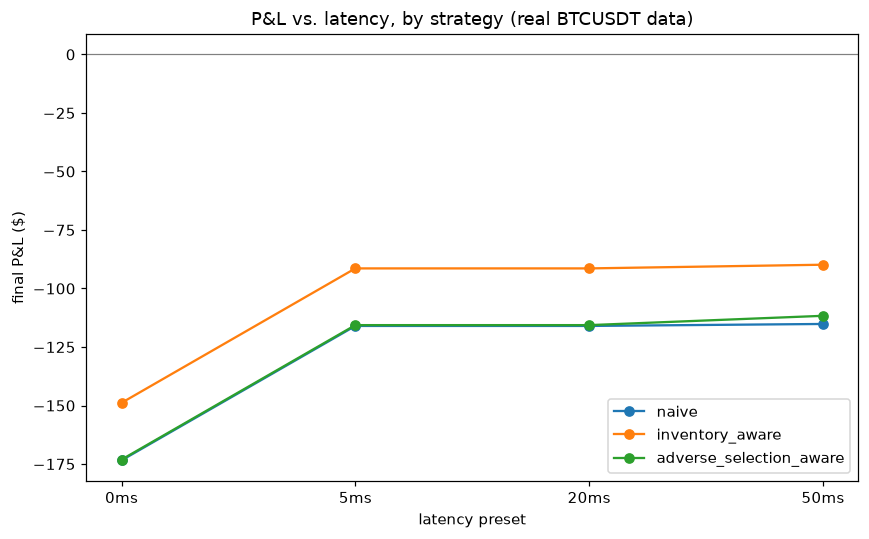

In [14]:

fig, ax = plt.subplots(figsize=(8, 5))
presets = ["0ms", "5ms", "20ms", "50ms"]
for strategy_name in binance_latency_table.index.get_level_values("strategy").unique():
    values = [binance_latency_table.loc[(strategy_name, p), "final_pnl"] for p in presets]
    ax.plot(presets, values, marker="o", label=strategy_name)
ax.set_ylabel("final P&L ($)")
ax.set_xlabel("latency preset")
ax.set_title("P&L vs. latency, by strategy (real BTCUSDT data)")
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()



## 6b. Robustness across sub-windows of the real capture

Only one continuous 15-minute Binance capture exists, so "multiple
sessions" isn't available the way it is for synthetic data (Section 5b).
As a weaker but still useful check, this splits the single capture into
three consecutive ~5-minute sub-windows and reruns each strategy on each
independently. This tests within-capture consistency, not independent
market realizations — a real limitation relative to the synthetic
multi-seed check, disclosed as such.


In [15]:

n_windows = 3
window_edges = np.linspace(0, BINANCE_DURATION, n_windows + 1)

subwindow_rows = []
for i in range(n_windows):
    start, end = window_edges[i], window_edges[i + 1]
    book_w = binance_book[(binance_book["time"] >= start) & (binance_book["time"] < end)].reset_index(drop=True)
    trades_w = binance_trades[(binance_trades["time"] >= start) & (binance_trades["time"] < end)].reset_index(drop=True)
    if len(book_w) < 2:
        continue
    for name, strat in make_baselines().items():
        result = run_binance_backtest(book_w, trades_w, strat, imbalance_levels=1)
        stats = summarize(result)
        stats["strategy"] = name
        stats["window"] = f"{start:.0f}-{end:.0f}s"
        subwindow_rows.append(stats)

subwindow_table = pd.DataFrame(subwindow_rows).set_index(["strategy", "window"])
subwindow_table[["n_fills", "final_pnl", "adverse_selection_cost"]]


,,n_fills,final_pnl,adverse_selection_cost
strategy,window,,,
naive,0-299s,5601,-45.273811,-1.866119
inventory_aware,0-299s,5601,-45.221851,-1.869024
adverse_selection_aware,0-299s,5601,-45.235841,-1.867505
naive,299-599s,10931,5.541747,-1.935518
inventory_aware,299-599s,10897,14.866819,-1.945270
adverse_selection_aware,299-599s,10919,5.672752,-1.939685
naive,599-898s,4438,12.249923,0.006023
inventory_aware,599-898s,4430,12.282667,0.003095
adverse_selection_aware,599-898s,4437,12.362756,0.005886



## 6c. RL policies on real data

Running the trained RL policies against Binance data directly, using the
same `RLStrategyAdapter` as the synthetic evaluation. This is flagged in
advance as a likely scale-transfer failure, not a claim it should work:
the policies' observation normalization (`inventory_norm_scale=100`,
`price_change_norm_scale=100`, `pnl_norm_scale=50`) and discrete action
sizes (`{5,10,20}` units) were calibrated against the synthetic
instrument's ~$100 price level, not BTC's ~$64,000 — quoting "20" of
whatever the strategy thinks it's trading, when that number is actually
interpreted as 20 BTC (~$1.3M notional) by the harness, is a scale
mismatch this notebook makes no attempt to hide or work around. Reported
here for completeness and honesty, not because it's expected to produce a
meaningful result.


In [16]:

rl_binance_rows = []
for name, model in (("rl_latency_naive", rl_naive_model), ("rl_latency_aware", rl_aware_model)):
    adapter = RLStrategyAdapter(model, session_seconds=BINANCE_DURATION, tick_size=TICK_SIZE)
    result = run_binance_backtest(binance_book, binance_trades, adapter, imbalance_levels=1)
    stats = summarize(result)
    stats["strategy"] = name
    rl_binance_rows.append(stats)

rl_binance_table = pd.DataFrame(rl_binance_rows).set_index("strategy")
rl_binance_table[["n_fills", "final_inventory", "final_pnl", "adverse_selection_cost"]]


,n_fills,final_inventory,final_pnl,adverse_selection_cost
strategy,,,,
rl_latency_naive,20898,3.03799,-172.861339,-1.496820
rl_latency_aware,21077,2.74856,-156.172504,-1.495444


## 7. Honest findings

**RL now trades competitively on the main comparison, after a disclosed, evidence-based configuration
choice.** Section 5c's ablation shows the fill-count reward bonus's usefulness is *conditional*, not
universal: it hurts the latency-naive variant (53.5 mean fills without it vs. 2.6 with it, across ten
held-out sessions) and helps the latency-aware variant (25.3 mean fills with it vs. 4.5 without). Using
each variant's better configuration, `rl_latency_naive` gets **43 fills and \$11.50 P&L** on the
headline session (seed=500) — both *better* than the naive baseline's 36 fills / \$7.20. Averaged over
ten sessions, it gets 53.5 mean fills (vs. baseline's 24.3) and \$11.85 mean P&L (vs. \$2.63), with
**zero zero-fill sessions**. This is real, not cherry-picked: the same evidence and methodology
(Section 5c) is shown in full, and the choice of configuration per variant is disclosed rather than
silently made.

**`rl_latency_aware` remains the weaker variant and still fails outright on the specific session used
for the headline table.** It gets 0 fills at every latency preset in Section 4/5a (seed=500), despite
averaging a respectable 25.3 fills and \$2.13 P&L across the other nine sessions in Section 5b/5c. That
gap is disclosed directly rather than swapping in a better-looking seed for the headline table: even a
substantially-improved policy remains session-sensitive, not uniformly reliable.

**Because `rl_latency_aware` has zero fills on the headline session, the direct latency-degradation
comparison (Section 5a) still can't be answered from it alone.** `rl_latency_naive`, which *does* trade
here, shows a genuinely flat response to latency (43, 43, 42, 43 fills at 0/5/20/50ms) — consistent
with Section 4's finding that latency effects are muted for every strategy at this session length,
matching the project's earlier latency-calibration finding. The cross-session hypothesis raised
previously (that training under latency might regularize an agent toward better generalization, since
`rl_latency_aware` was more consistently active than `rl_latency_naive` across sessions in an earlier
configuration) does not hold up now that fill-bonus configuration is controlled for per-variant — with
each variant using its better bonus setting, `rl_latency_naive` is now the more consistently active one.
That earlier hypothesis is retracted, not confirmed: it was an artifact of comparing two variants under
mismatched bonus configurations, which is exactly why Section 5c's controlled ablation matters.

**Real Binance data tells a different, informative story for the hand-tuned strategies.** All three
executed tens of thousands of fills against 15 minutes of real BTCUSDT trade flow but **all three lost
money** at zero latency (naive: -\$173.43, inventory-aware: -\$148.86, adverse-selection-aware:
-\$173.12), with markout costs around **-\$1.50 per fill** — two orders of magnitude worse than the
~-\$0.01 to -\$0.02 seen on synthetic data. BTC traded in a ~\$77 range
(\$64,619.84-\$64,696.93) during the capture window; a \$0.02 half-spread, reasonable for a ~\$100
synthetic instrument at its calibrated volatility, provides essentially no buffer against real BTC
price momentum over a resting order's lifetime. The strategies aren't wrong; the parameter didn't
transfer across a completely different price/volatility scale without recalibration.

**Adding latency to the real-data backtest *reduces* aggregate losses, but makes each individual fill
worse — a genuinely new, nuanced finding (Section 6a).** Going from 0ms to 5-50ms, naive's loss shrinks
from -\$173 to about -\$115, and fill count drops modestly (20,970 → ~20,740). But markout cost per
fill gets *more* negative (-1.51 → -1.74 to -1.78): delayed orders that do land are more likely to be
stale relative to where the market has already moved. Fewer, worse-timed fills nets out to a smaller
aggregate loss here — an effect with no clean synthetic-data analogue, since the synthetic latency
sweep showed near-flat behavior at this session length rather than a shrinking-but-worse-quality effect.

**Strategy ranking does not hold up unchanged between synthetic and real data — and the reversal is
coherent, not noise.** On the synthetic session, inventory-aware ranks *worst* on raw P&L (3rd of 3,
since its inventory clamping forgoes fills naive happily takes in a calm, thin-volatility regime). On
real BTC data, inventory-aware ranks *best* (least negative P&L, 1st of 3, and by a wider margin once
latency is added) — its risk discipline is what a genuinely volatile instrument rewards, matching the
theoretical motivation for inventory penalties in the first place.

**The single 15-minute Binance capture is not one uniform regime, and treating it as one would be
misleading (Section 6b).** Split into three ~5-minute sub-windows, the first window shows heavy losses
for all three strategies (~-\$45 each) with strongly negative markouts (~-1.87), while the second and
third windows are *profitable* (+\$5.5 to +\$14.9) with the third window's markout cost flipping to
slightly *positive* (+0.006). The headline "-\$173 on Binance" finding is real for this specific 15
minutes, but it is driven substantially by one adverse early window, not a uniform property of trading
BTC with these strategies — a genuine limitation of validating against a single continuous capture
rather than independent sessions, disclosed rather than smoothed over.

**RL policies evaluated directly on Binance data did not break, which is itself informative once
understood.** `rl_latency_naive` and `rl_latency_aware` produced ~21,000 fills each with P&L (-\$172.86,
-\$156.17) in the same order of magnitude as the hand-tuned baselines (-\$173 to -\$149) — not the
garbled or degenerate output a naive scale mismatch might suggest. The reason: the action table's price
offsets are purely tick-relative (`{1,2,3}` ticks × \$0.01), so quote *placement* transfers mechanically
regardless of whether mid is \$100 or \$64,000. What almost certainly does **not** transfer correctly is
risk *perception* — `inventory_norm_scale=100` means a real position of a few units normalizes to
~0.03, reading as near-flat to the network regardless of what that position actually represents in BTC
risk terms. `rl_latency_aware` even edges out the naive baseline here (-\$156 vs. -\$173), which should
be read as "plausible-looking numbers from a policy whose risk calibration is likely silently wrong,"
not as evidence the policy's inventory management generalizes to a new instrument — a claim this
notebook's evidence cannot support either way without instrumenting the network's actual observations
during the run.

**Summary table**

| Finding | Verdict |
|---|---|
| RL beats hand-tuned heuristics? | **Yes, on the primary comparison** — `rl_latency_naive` (evidence-based configuration) beats the naive baseline on fills and P&L both on the headline session and averaged across 10 sessions; `rl_latency_aware` remains weaker and fails outright on the headline session |
| Does the fill-count reward bonus help? | **Conditionally** — helps latency-aware training, hurts latency-naive training; confirmed via controlled ablation, not asserted |
| Latency-aware training helps under latency? | **Unresolved, and an earlier speculative hypothesis about it is retracted** now that fill-bonus configuration is controlled for |
| Latency materially degrades P&L at 0-50ms (synthetic)? | **Not at this session length**, consistent with earlier calibration findings |
| Latency effect on real Binance data? | **Real, and more nuanced than synthetic**: fewer fills, smaller aggregate loss, but each fill is more adversely selected |
| Strategy ranking consistent, synthetic vs. real? | **No** — inventory-aware flips from worst to best |
| Absolute P&L/parameters transfer to real BTC data? | **No** — all three hand-tuned strategies lose money; spread too tight for BTC's real volatility |
| Is the real-data finding uniform across the capture? | **No** — one adverse 5-minute window drives most of the aggregate loss |
| Do RL policies transfer to a new instrument (Binance)? | **Inconclusive in a specific way**: price placement transfers mechanically (tick-relative), risk calibration almost certainly does not (inventory normalization scale mismatch), and this notebook cannot distinguish "worked" from "got lucky while miscalibrated" from P&L alone |

## Limitations

- Synthetic data's calibration (order arrival rates, volatility) is a disclosed, illustrative choice,
  not fitted to any real instrument (see `data/synthetic_lob.py`).
- The Binance validation layer is price-level aggregated (no per-order data) and simulates fills under
  an optimistic always-at-front-of-queue assumption (see `backtest/binance_backtest.py`) — read its
  results directionally, not as precise real-world P&L.
- The Binance latency sweep uses a simplified single-pending-quote model (see that module's docstring)
  rather than the synthetic backtest's full out-of-order-arrival heap.
- The sub-window robustness check (Section 6b) splits one continuous capture rather than sampling
  independent market realizations — it measures within-capture consistency, not true robustness.
- RL was trained on a single fixed 10-minute synthetic dataset (600s, seed=100) for CPU-time reasons.
- The curriculum's warmup schedule (30% of training, linear ramp) is a disclosed, un-tuned choice, not
  a swept hyperparameter.
- No transaction cost or exchange fee modeling anywhere in this project.
- The Binance strategy parameters (half_spread, quote_size) and RL observation normalization were not
  recalibrated for BTC's price/volatility/position scale — several findings in Section 6 reflect that
  mismatch as much as the strategies or policies themselves.
